📂 Cargando datos...
✓ 249 frames cargados

ALINEACIÓN SIM(3) Y CÁLCULO DE MÉTRICAS

🟢 SIFT Classic:
   Escala (s):      0.6660
   ATE RMSE:        12.100 m
   RPE RMSE (Δ5):   1.321 m

🟣 SIFT Kornia:
   Escala (s):      0.6723
   ATE RMSE:        11.603 m
   RPE RMSE (Δ5):   1.294 m

📊 Comparación:
   Classic es 0.96x más preciso que Kornia


📏 Límites: X=[-26.9, 124.1], Z=[-14.3, 156.9]



<Figure size 2000x1000 with 0 Axes>

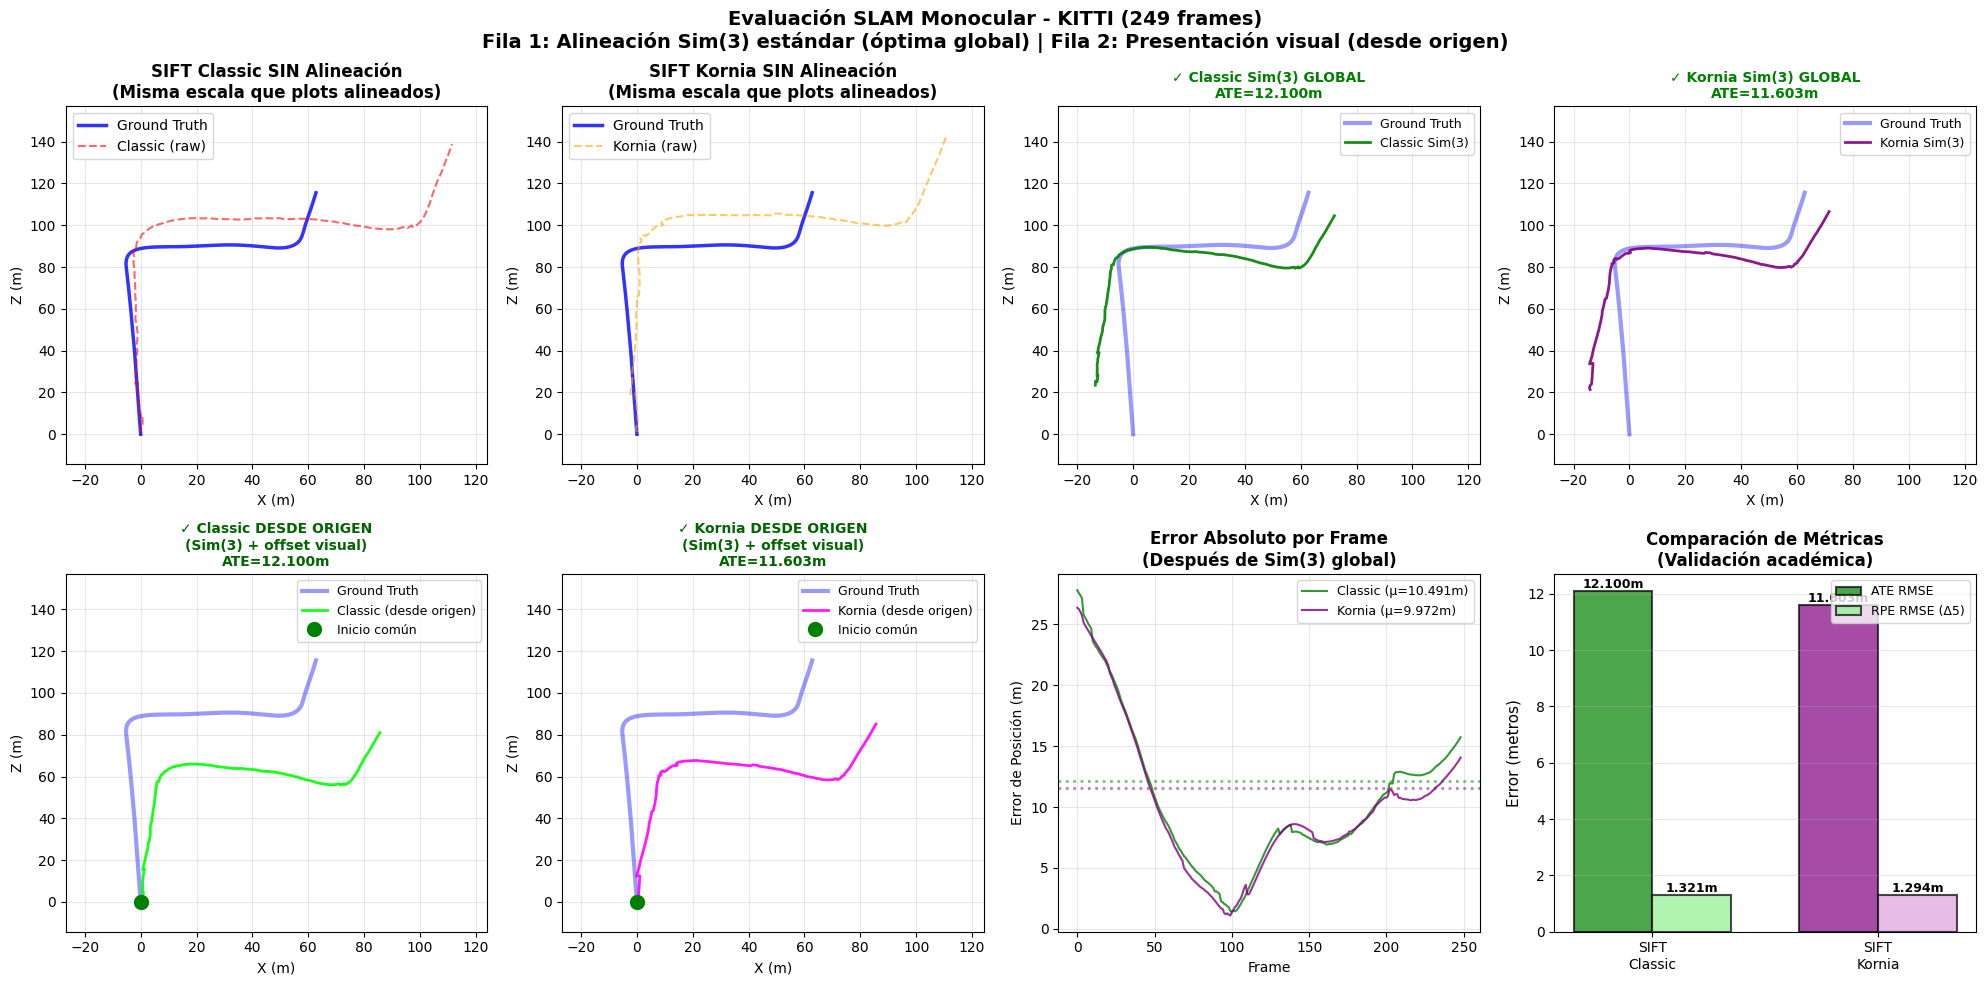

✓ Análisis completo guardado: outputs/benchmarks/slam_analysis_complete.png

TABLA DE RESULTADOS FINALES

Método          ATE (m)      RPE Δ5 (m)   Escala   Frames  
----------------------------------------------------------------------
SIFT Classic    12.100       1.321        0.666    249     
SIFT Kornia     11.603       1.294        0.672    249     

✓ Resultados exportados: ../outputs/benchmarks/final_results.json


In [2]:
# ============================================================================
# ANÁLISIS COMPLETO: Visual SLAM vs Ground Truth KITTI
# ============================================================================

import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.linalg import orthogonal_procrustes

# ============================================================================
# SECCIÓN 1: FUNCIONES DE ALINEACIÓN SIM(3)
# ============================================================================

def align_sim3_umeyama(source: np.ndarray, target: np.ndarray) -> tuple:
    """
    Alineación Sim(3) usando Umeyama (1991)
    Transformación: target ≈ s * R @ source + t
    """
    mu_source = source.mean(axis=0)
    mu_target = target.mean(axis=0)
    
    source_centered = source - mu_source
    target_centered = target - mu_target
    
    H = source_centered.T @ target_centered
    U, D, Vt = np.linalg.svd(H)
    
    S = np.eye(3)
    if np.linalg.det(U @ Vt) < 0:
        S[2, 2] = -1
    
    R = U @ S @ Vt
    
    # Escala
    source_rotated = (R @ source_centered.T).T
    numerator = np.sum(target_centered * source_rotated)
    denominator = np.sum(source_rotated ** 2)
    s = numerator / denominator if denominator > 1e-10 else 1.0
    s = abs(s)
    
    t = mu_target - s * R @ mu_source
    
    # Validar
    source_aligned = s * (R @ source.T).T + t
    error = np.sqrt(np.mean(np.sum((source_aligned - target) ** 2, axis=1)))
    
    return R, t, s, error


def compute_ate(estimated_aligned: np.ndarray, ground_truth: np.ndarray) -> dict:
    """Calcula ATE después de alineación"""
    errors = np.linalg.norm(estimated_aligned - ground_truth, axis=1)
    return {
        'rmse': np.sqrt(np.mean(errors ** 2)),
        'mean': np.mean(errors),
        'std': np.std(errors),
        'median': np.median(errors),
        'min': np.min(errors),
        'max': np.max(errors)
    }


def compute_rpe(estimated_aligned: np.ndarray, ground_truth: np.ndarray, delta: int = 5) -> dict:
    """Calcula RPE con separación delta frames"""
    est_deltas = estimated_aligned[delta:] - estimated_aligned[:-delta]
    gt_deltas = ground_truth[delta:] - ground_truth[:-delta]
    errors = np.linalg.norm(est_deltas - gt_deltas, axis=1)
    
    return {
        'rmse': np.sqrt(np.mean(errors ** 2)),
        'mean': np.mean(errors),
        'median': np.median(errors),
        'delta': delta
    }


# ============================================================================
# SECCIÓN 2: CARGAR DATOS
# ============================================================================

def load_trajectory_json(filepath: str) -> np.ndarray:
    """Carga trayectoria desde JSON"""
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    traj = data['trajectory']
    
    # Manejar formato 2D (x, z) o 3D (x, y, z)
    if 'y' in traj:
        return np.array([[traj['x'][i], traj['y'][i], traj['z'][i]] 
                        for i in range(len(traj['x']))])
    else:
        return np.array([[traj['x'][i], 0.0, traj['z'][i]] 
                        for i in range(len(traj['x']))])


# Cargar datos
print("📂 Cargando datos...")

gt = load_trajectory_json('../outputs/benchmarks/ground_truth_trajectory.json')
classic = load_trajectory_json('../outputs/benchmarks/sift_classic_trajectory.json')
kornia = load_trajectory_json('../outputs/benchmarks/sift_kornia_trajectory.json')

# Ajustar longitud
min_len = min(len(gt), len(classic), len(kornia))
gt = gt[:min_len]
classic_raw = classic[:min_len]
kornia_raw = kornia[:min_len]

print(f"✓ {min_len} frames cargados\n")


# ============================================================================
# SECCIÓN 3: ALINEACIÓN SIM(3) Y MÉTRICAS
# ============================================================================

print("="*70)
print("ALINEACIÓN SIM(3) Y CÁLCULO DE MÉTRICAS")
print("="*70)

# SIFT Classic
R_c, t_c, s_c, err_c = align_sim3_umeyama(classic_raw, gt)
classic_aligned = s_c * (R_c @ classic_raw.T).T + t_c

ate_c = compute_ate(classic_aligned, gt)
rpe_c = compute_rpe(classic_aligned, gt, delta=5)

print(f"\n🟢 SIFT Classic:")
print(f"   Escala (s):      {s_c:.4f}")
print(f"   ATE RMSE:        {ate_c['rmse']:.3f} m")
print(f"   RPE RMSE (Δ5):   {rpe_c['rmse']:.3f} m")

# SIFT Kornia
R_k, t_k, s_k, err_k = align_sim3_umeyama(kornia_raw, gt)
kornia_aligned = s_k * (R_k @ kornia_raw.T).T + t_k

ate_k = compute_ate(kornia_aligned, gt)
rpe_k = compute_rpe(kornia_aligned, gt, delta=5)

print(f"\n🟣 SIFT Kornia:")
print(f"   Escala (s):      {s_k:.4f}")
print(f"   ATE RMSE:        {ate_k['rmse']:.3f} m")
print(f"   RPE RMSE (Δ5):   {rpe_k['rmse']:.3f} m")

print(f"\n📊 Comparación:")
print(f"   Classic es {ate_k['rmse']/ate_c['rmse']:.2f}x más preciso que Kornia")
print("="*70 + "\n")


# ============================================================================
# VISUALIZACIÓN COMPLETA: 8 GRÁFICAS (2 filas x 4 columnas)
# ============================================================================

def align_to_origin(trajectory_aligned, gt):
    """Post-procesa Sim(3) para que frame 0 coincida (solo visual)"""
    offset = gt[0] - trajectory_aligned[0]
    return trajectory_aligned + offset


fig = plt.figure(figsize=(20, 10))

# ============================================================================
# CALCULAR LÍMITES GLOBALES
# ============================================================================
all_x = np.concatenate([gt[:, 0], classic_raw[:, 0], kornia_raw[:, 0], 
                        classic_aligned[:, 0], kornia_aligned[:, 0]])
all_z = np.concatenate([gt[:, 2], classic_raw[:, 2], kornia_raw[:, 2], 
                        classic_aligned[:, 2], kornia_aligned[:, 2]])

x_min, x_max = all_x.min(), all_x.max()
z_min, z_max = all_z.min(), all_z.max()
margin_x = (x_max - x_min) * 0.1
margin_z = (z_max - z_min) * 0.1
x_lim = [x_min - margin_x, x_max + margin_x]
z_lim = [z_min - margin_z, z_max + margin_z]

print(f"\n📏 Límites: X=[{x_lim[0]:.1f}, {x_lim[1]:.1f}], Z=[{z_lim[0]:.1f}, {z_lim[1]:.1f}]\n")

# ============================================================================
# VISUALIZACIÓN CON LÍMITES FIJOS
# ============================================================================
fig = plt.figure(figsize=(20, 10))

# Plot 1: Classic RAW
ax1 = plt.subplot(2, 4, 1)
ax1.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=2.5, label='Ground Truth', alpha=0.8)
ax1.plot(classic_raw[:, 0], classic_raw[:, 2], 'r--', linewidth=1.5, label='Classic (raw)', alpha=0.6)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Z (m)')
ax1.set_title('SIFT Classic SIN Alineación\n(Misma escala que plots alineados)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(x_lim)  # ← FIJO
ax1.set_ylim(z_lim)  # ← FIJO

# Plot 2: Kornia RAW
ax2 = plt.subplot(2, 4, 2)
ax2.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=2.5, label='Ground Truth', alpha=0.8)
ax2.plot(kornia_raw[:, 0], kornia_raw[:, 2], 'orange', linestyle='--', linewidth=1.5, label='Kornia (raw)', alpha=0.6)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Z (m)')
ax2.set_title('SIFT Kornia SIN Alineación\n(Misma escala que plots alineados)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(x_lim)  # ← FIJO
ax2.set_ylim(z_lim)  # ← FIJO

# Plot 3: Classic Sim(3) GLOBAL
ax3 = plt.subplot(2, 4, 3)
ax3.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=3, label='Ground Truth', alpha=0.4)
ax3.plot(classic_aligned[:, 0], classic_aligned[:, 2], 'g-', linewidth=2, label=f'Classic Sim(3)', alpha=0.9)
ax3.set_xlabel('X (m)')
ax3.set_ylabel('Z (m)')
ax3.set_title(f'✓ Classic Sim(3) GLOBAL\nATE={ate_c["rmse"]:.3f}m', fontweight='bold', color='green', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(x_lim)  # ← FIJO
ax3.set_ylim(z_lim)  # ← FIJO

# Plot 4: Kornia Sim(3) GLOBAL
ax4 = plt.subplot(2, 4, 4)
ax4.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=3, label='Ground Truth', alpha=0.4)
ax4.plot(kornia_aligned[:, 0], kornia_aligned[:, 2], 'purple', linewidth=2, label=f'Kornia Sim(3)', alpha=0.9)
ax4.set_xlabel('X (m)')
ax4.set_ylabel('Z (m)')
ax4.set_title(f'✓ Kornia Sim(3) GLOBAL\nATE={ate_k["rmse"]:.3f}m', fontweight='bold', color='green', fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(x_lim)  # ← FIJO
ax4.set_ylim(z_lim)  # ← FIJO



# ========== FILA 2: CON ALINEACIÓN DESDE ORIGEN (VISUAL) ==========

# Aplicar offset visual
classic_plot = align_to_origin(classic_aligned, gt)
kornia_plot = align_to_origin(kornia_aligned, gt)

# Plot 5: Classic DESDE ORIGEN (presentación)
ax5 = plt.subplot(2, 4, 5)
ax5.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=3, label='Ground Truth', alpha=0.4)
ax5.plot(classic_plot[:, 0], classic_plot[:, 2], 'lime', linewidth=2, 
         label=f'Classic (desde origen)', alpha=0.9)
ax5.plot(gt[0, 0], gt[0, 2], 'go', markersize=10, label='Inicio común', zorder=5)
ax5.set_xlabel('X (m)')
ax5.set_ylabel('Z (m)')
ax5.set_title(f'✓ Classic DESDE ORIGEN\n(Sim(3) + offset visual)\nATE={ate_c["rmse"]:.3f}m', 
              fontweight='bold', color='darkgreen', fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)
ax5.set_xlim(x_lim)  # ← FIJO
ax5.set_ylim(z_lim)  # ← FIJO

# Plot 6: Kornia DESDE ORIGEN
ax6 = plt.subplot(2, 4, 6)
ax6.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=3, label='Ground Truth', alpha=0.4)
ax6.plot(kornia_plot[:, 0], kornia_plot[:, 2], 'magenta', linewidth=2, 
         label=f'Kornia (desde origen)', alpha=0.9)
ax6.plot(gt[0, 0], gt[0, 2], 'go', markersize=10, label='Inicio común', zorder=5)
ax6.set_xlabel('X (m)')
ax6.set_ylabel('Z (m)')
ax6.set_title(f'✓ Kornia DESDE ORIGEN\n(Sim(3) + offset visual)\nATE={ate_k["rmse"]:.3f}m', 
              fontweight='bold', color='darkgreen', fontsize=10)
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)
ax6.set_xlim(x_lim)  # ← FIJO
ax6.set_ylim(z_lim)  # ← FIJO

# Plot 7: Error por Frame
ax7 = plt.subplot(2, 4, 7)
errors_c = np.linalg.norm(classic_aligned - gt, axis=1)  # ← Usar aligned original
errors_k = np.linalg.norm(kornia_aligned - gt, axis=1)

frames = np.arange(len(errors_c))
ax7.plot(frames, errors_c, 'g-', linewidth=1.5, label=f'Classic (μ={ate_c["mean"]:.3f}m)', alpha=0.8)
ax7.plot(frames, errors_k, 'purple', linewidth=1.5, label=f'Kornia (μ={ate_k["mean"]:.3f}m)', alpha=0.8)
ax7.axhline(ate_c['rmse'], color='g', linestyle=':', alpha=0.5, linewidth=2)
ax7.axhline(ate_k['rmse'], color='purple', linestyle=':', alpha=0.5, linewidth=2)
ax7.set_xlabel('Frame')
ax7.set_ylabel('Error de Posición (m)')
ax7.set_title('Error Absoluto por Frame\n(Después de Sim(3) global)', fontweight='bold')
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.3)

# Plot 8: Comparación Métricas
ax8 = plt.subplot(2, 4, 8)
methods = ['SIFT\nClassic', 'SIFT\nKornia']
ate_values = [ate_c['rmse'], ate_k['rmse']]
rpe_values = [rpe_c['rmse'], rpe_k['rmse']]

x = np.arange(len(methods))
width = 0.35

bars1 = ax8.bar(x - width/2, ate_values, width, label='ATE RMSE', 
                color=['green', 'purple'], alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = ax8.bar(x + width/2, rpe_values, width, label='RPE RMSE (Δ5)', 
                color=['lightgreen', 'plum'], alpha=0.7, edgecolor='black', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}m', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax8.set_ylabel('Error (metros)', fontsize=11)
ax8.set_title('Comparación de Métricas\n(Validación académica)', fontweight='bold')
ax8.set_xticks(x)
ax8.set_xticklabels(methods)
ax8.legend(fontsize=9)
ax8.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Evaluación SLAM Monocular - KITTI ({min_len} frames)\n' +
             'Fila 1: Alineación Sim(3) estándar (óptima global) | Fila 2: Presentación visual (desde origen)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/benchmarks/slam_analysis_complete.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Análisis completo guardado: outputs/benchmarks/slam_analysis_complete.png")

# ============================================================================
# SECCIÓN 5: TABLA DE RESULTADOS
# ============================================================================

print("\n" + "="*70)
print("TABLA DE RESULTADOS FINALES")
print("="*70)
print(f"\n{'Método':<15} {'ATE (m)':<12} {'RPE Δ5 (m)':<12} {'Escala':<8} {'Frames':<8}")
print("-"*70)
print(f"{'SIFT Classic':<15} {ate_c['rmse']:<12.3f} {rpe_c['rmse']:<12.3f} {s_c:<8.3f} {min_len:<8}")
print(f"{'SIFT Kornia':<15} {ate_k['rmse']:<12.3f} {rpe_k['rmse']:<12.3f} {s_k:<8.3f} {min_len:<8}")
print("="*70 + "\n")

# Exportar JSON
results = {
    'classic': {
        'ate': ate_c,
        'rpe': rpe_c,
        'scale': float(s_c),
        'frames': min_len
    },
    'kornia': {
        'ate': ate_k,
        'rpe': rpe_k,
        'scale': float(s_k),
        'frames': min_len
    }
}

with open('../outputs/benchmarks/final_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✓ Resultados exportados: ../outputs/benchmarks/final_results.json")